# 1. Первичный анализ и обработка датафрейма

In [496]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [497]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')

In [498]:
sber

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,SBRF,1,20090111,103000,2301,2335,2301,2321,123
1,SBRF,1,20090111,103100,2321,2321,2265,2269,194
2,SBRF,1,20090111,103200,2310,2344,2310,2344,383
3,SBRF,1,20090111,103300,2344,2346,2333,2333,67
4,SBRF,1,20090111,103400,2334,2334,2334,2334,2
...,...,...,...,...,...,...,...,...,...
3298843,SBRF,1,20250630,234400,29851,29851,29845,29845,28
3298844,SBRF,1,20250630,234500,29843,29845,29829,29845,39
3298845,SBRF,1,20250630,234700,29828,29828,29827,29827,3
3298846,SBRF,1,20250630,234800,29832,29841,29805,29815,262


In [499]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result


In [500]:
sber_1h = good_dataframe(sber, '4h')
sber_1h

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 08:00:00,SBRF,4h,2301.0,2380.0,2265.0,2346.0,13466
1,2009-01-11 12:00:00,SBRF,4h,2346.0,2354.0,2319.0,2320.0,5528
2,2009-01-11 16:00:00,SBRF,4h,2321.0,2358.0,2319.0,2343.0,6260
3,2009-01-11 20:00:00,SBRF,4h,2343.0,2359.0,2335.0,2353.0,1250
4,2009-01-12 08:00:00,SBRF,4h,2345.0,2353.0,2323.0,2333.0,10626
...,...,...,...,...,...,...,...,...
16656,2025-06-27 20:00:00,SBRF,4h,29733.0,29745.0,29651.0,29686.0,6944
16657,2025-06-30 08:00:00,SBRF,4h,29750.0,29975.0,29679.0,29686.0,71639
16658,2025-06-30 12:00:00,SBRF,4h,29687.0,29870.0,29646.0,29838.0,40482
16659,2025-06-30 16:00:00,SBRF,4h,29839.0,29900.0,29793.0,29859.0,20053


# 2. Детекторы свечных паттернов
- Бычье поглощение / Медвежье поглощение - надо проверить
- Харами - надо проверить
- 3 свечи - надо проверить

Далее
- 3 звезды
- Пинцет
- Захват за пояс
- Просвет в облаках

- Повешенный или молот (надо оптимизировать размер тени)

## 1. Бычье поглощение / Медвежье поглощение
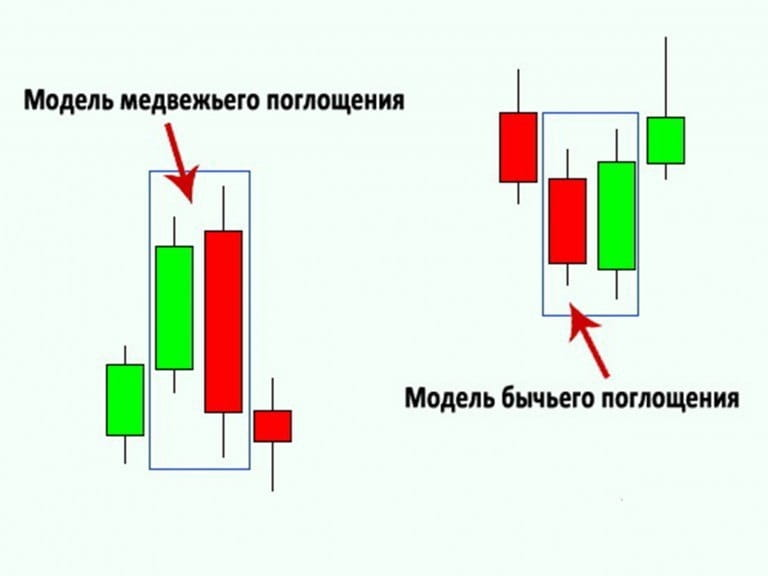

In [501]:
def detection_bullish_engulfing_pattern(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных.
    Функция позволяет применять дополнительные фильтры для подтверждения надежности паттерна.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_grow_candle_after_pattern' - паттерн подтверждается 1 растущей свечой после него
        - '2_grow_candle_after_pattern' - паттерн подтверждается 2 растущими свечами после него
        
        - '1_loss_candle_before_pattern' - паттерн подтверждается 1 падающей свечой до него  
        - '2_loss_candle_before_pattern' - паттерн подтверждается 2 падающими свечами до него
        
        - 'full_engulfing' - полное поглощение предыдущей свечи (вместе с тенями)
        

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий 
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body < 0) & 
        (body.shift(-1) > 0) &
        (data['open'] < data['close'].shift(-1)) & 
        (data['close'] > data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) > 0) & (body.shift(-3) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0) & (body.shift(2) < 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == 'full_engulfing':
        # Полное поглощение с тенями
        pattern_mask = (
            (body < 0) & 
            (body.shift(-1) > 0) &
            (data['close'].shift(-1) > data['high']) & 
            (data['open'].shift(-1) < data['low'])
        )
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
    
    return data
        

In [502]:
def detection_bearish_engulfing_pattern(data, filtr='NO'):
    """
    Функция для детекции медвежьего паттерна 'поглощение' (Bearish Engulfing) на ценовых данных.
    Функция позволяет применять дополнительные фильтры для подтверждения надежности паттерна.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения медвежьим движением:
        - '1_loss_candle_after_pattern' - паттерн подтверждается 1 падающей свечой после него
        - '2_loss_candle_after_pattern' - паттерн подтверждается 2 падающими свечами после него
        
        - '1_grow_candle_before_pattern' - паттерн подтверждается 1 растущей свечой до него  
        - '2_grow_candle_before_pattern' - паттерн подтверждается 2 растущими свечами до него
        
        - 'full_engulfing' - полное поглощение следующей свечей максимумом и минимумов предыдущей свечи
    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленными колонками:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий
        
    """
    
    
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body > 0) & 
        (body.shift(-1) < 0) &
        (data['open'] > data['close'].shift(-1)) & 
        (data['close'] < data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) < 0) & (body.shift(-3) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0) & (body.shift(2) > 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == 'full_engulfing':
        # Полное поглощение с тенями
        pattern_mask = (
            (body > 0) & 
            (body.shift(-1) < 0) &
            (data['open'].shift(-1) > data['high']) & 
            (data['close'].shift(-1) < data['low'])
        )
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
    
    return data

## 2. Харами
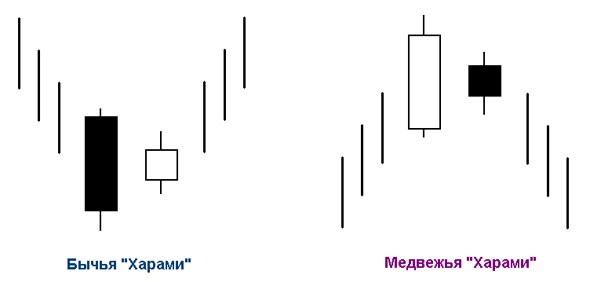

In [ ]:
def detection_bullish_harami_pattern(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_grow_candle_after_pattern' - паттерн подтверждается 1 растущей свечой после него
        - '2_grow_candle_after_pattern' - паттерн подтверждается 2 растущими свечами после него
        
        - '1_loss_candle_before_pattern' - паттерн подтверждается 1 падающей свечой до него  
        - '2_loss_candle_before_pattern' - паттерн подтверждается 2 падающими свечами до него
        
        - 'full_harami' - полное содержание следующей свечи в пределах тела предыдущей (включая тени)

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий 
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body < 0) & 
        (body.shift(-1) > 0) &
        (data['open'] > data['close'].shift(-1)) & 
        (data['close'] < data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) > 0) & (body.shift(-3) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0) & (body.shift(2) < 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == 'full_hurami':
        # Полное поглощение с тенями
        pattern_mask = (
            (body < 0) & 
            (body.shift(-1) > 0) &
            (data['close'] < data['low'].shift(-1)) & 
            (data['open'] > data['high'].shift(-1))
        )
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
    
    return data
        

In [514]:
def detection_bearish_harami(data, filtr='NO'):
    """
    Функция для детекции медвежьего паттерна 'харами' (Bearish Harami) на ценовых данных.
    Паттерн Харами состоит из большой бычьей свечи, за которой следует маленькая медвежья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи. Является сигналом разворота вниз.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения медвежьим движением:
        - '1_loss_candle_after_pattern' - паттерн подтверждается 1 падающей свечой после него
        - '2_loss_candle_after_pattern' - паттерн подтверждается 2 падающими свечами после него
        
        - '1_grow_candle_before_pattern' - паттерн подтверждается 1 растущей свечой до него  
        - '2_grow_candle_before_pattern' - паттерн подтверждается 2 растущими свечами до него
        
        - 'full_harami' - полное содержание следующей свечи в пределах тела предыдущей (включая тени)

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
    """
    
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие медвежьего харами
    base_condition = (
        (body > 0) & 
        (body.shift(-1) < 0) &
        (data['open'] < data['close'].shift(-1)) & 
        (data['close'] > data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) < 0) & (body.shift(-3) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0) & (body.shift(2) > 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == 'full_engulfing':
        # Полное поглощение с тенями
        pattern_mask = (
            (body > 0) & 
            (body.shift(-1) < 0) &
            (data['open'] < data['low'].shift(-1)) & 
            (data['close'] > data['high'].shift(-1))
        )
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
    
    return data


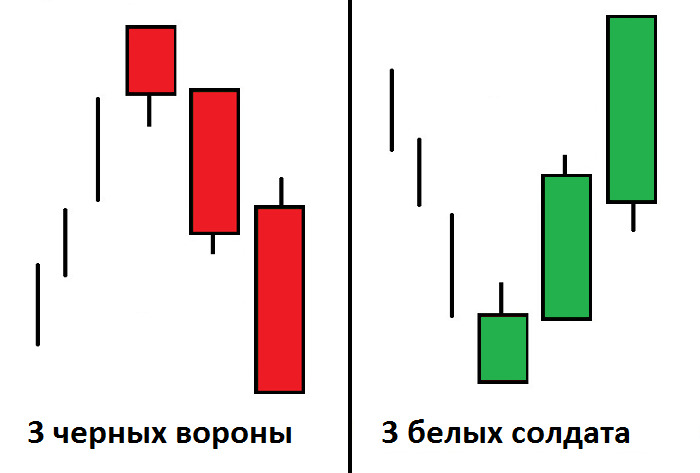

In [506]:
def detection_3_grow_candle(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 3 растущих свеч на ценовых данныx.
    

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_loss_candle_after_pattern' - паттерн подтверждается 1 падающей свечой после него
        - '1_loss_candle_before_pattern' - паттерн подтверждается 1 падающей свечой до него  

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие 
    base_condition = (
        (body > 0) & 
        (body.shift(-1) > 0) &
        (body.shift(-2) > 0))

    if filtr == 'NO':
        # Отмечаем 3 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_after_pattern':
        # 4 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-3) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_before_pattern':
        # 4 свечи: паттерн + 1 подтверждения
        pattern_mask = base_condition & (body.shift(1) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    
    return data
    
       

In [507]:
def detection_3_loss_candle(data, filtr='NO'):
    """
    Функция для детекции медвежьего паттерна 3 падающих свеч на ценовых данныx.
    

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_grow_candle_after_pattern' - паттерн подтверждается 1 растущей свечой после него
        - '1_grow_candle_before_pattern' - паттерн подтверждается 1 растущей свечой до него  

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие 
    base_condition = (
        (body < 0) & 
        (body.shift(-1) < 0) &
        (body.shift(-2) < 0))

    if filtr == 'NO':
        # Отмечаем 3 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_after_pattern':
        # 4 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-3) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_before_pattern':
        # 4 свечи: паттерн + 1 подтверждения
        pattern_mask = base_condition & (body.shift(1) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    
    return data
    
       

# Проверка эффективности паттернов

In [508]:
def calculate_trade_statistics(data, commision=0.01, full='NO', direction='bull'):
    if direction == 'bull':
        def lst_trade_statistics_bull(data, commision=commision):
            # Указываем максимальный размер датасета
            max_index = len(data) - 50
            # список для результатов
            all_results = []
            signal_indices = data.index[data['signal'] == 1]
            signal_indices = signal_indices[signal_indices < max_index]
            for i in range(1, 51):
                entry_indices = signal_indices
                exit_indicies = signal_indices + i 
                # Проверяем корректность индексов
                valid_mask = exit_indicies < len(data)
                valid_entry_indices = entry_indices[valid_mask]
                valid_exit_indicies = exit_indicies[valid_mask]
                
                entry_price = data['open'].iloc[valid_entry_indices].values
                exit_price = data['close'].iloc[valid_exit_indicies].values
                profit = exit_price - entry_price
                commision = commision
                profit_net = np.where(profit > 0, profit * (1 - commision), profit * (1 + commision))
                all_results.append(profit_net)
            return all_results
    
        lst = lst_trade_statistics_bull(data)
    
    elif direction == 'bear':
        def lst_trade_statistics_bear(data, commision=commision):
            # Указываем максимальный размер датасета
            max_index = len(data) - 50
            # список для результатов
            all_results = []
            signal_indices = data.index[data['signal'] == 1]
            signal_indices = signal_indices[signal_indices < max_index]
            for i in range(1, 51):
                entry_indices = signal_indices
                exit_indicies = signal_indices + i 
                # Проверяем корректность индексов
                valid_mask = exit_indicies < len(data)
                valid_entry_indices = entry_indices[valid_mask]
                valid_exit_indicies = exit_indicies[valid_mask]
                
                entry_price = data['open'].iloc[valid_entry_indices].values
                exit_price = data['close'].iloc[valid_exit_indicies].values
                profit = entry_price - exit_price
                commision = commision
                profit_net = np.where(profit > 0, profit * (1 - commision), profit * (1 + commision))
                all_results.append(profit_net)
            return all_results
    
        lst = lst_trade_statistics_bear(data)
    
    def calculate_relative_drawdown(lst):
        cumulative = np.cumsum(lst)
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (running_max - cumulative) 
        return np.max(drawdown)
        
    # Предварительно создаем шаблоны словарей
    template_full = {
        'n': 0.0, 'profit': 0.0, 'profit_net': 0.0, 'loss_net': 0.0,
        'count_of_trade': 0.0, 'percent_of_profit_trade': 0.0, 
        'percent_of_loss_trade': 0.0, 'std_profit': 0.0,
        'avg_profit_trade': 0.0, 'avg_loss_trade': 0.0,
        'profit_factor': 0.0, 'max_drawdown': 0.0, 'cumsum': 0.0
    }
    
    template_short = {
        'n': 0.0, 'profit': 0.0, 'count_of_trade': 0.0,
        'percent_of_profit_trade': 0.0, 'percent_of_loss_trade': 0.0,
        'profit_factor': 0.0, 'max_drawdown': 0.0
    }
    
    results = []
    
    for n, returns in enumerate(lst, 1):
        returns = np.array(returns)
        
        if len(returns) == 0:
            # Пустые результаты
            if full == 'YES':
                result = template_full.copy()
                result['n'] = n
                results.append(result)
            else:
                result = template_short.copy()
                result['n'] = n
                results.append(result)
            continue
        
        # Векторизованные вычисления
        is_positive = returns > 0
        positive_returns = returns[is_positive]
        negative_returns = returns[~is_positive]
        
        profit_total = np.sum(returns)
        profit_net = np.sum(positive_returns)
        loss_net = np.sum(negative_returns)
        count_trades = len(returns)
        percent_profit = np.mean(is_positive) * 100
        percent_loss = 100 - percent_profit
        profit_factor = profit_net / abs(loss_net) if loss_net < 0 else float('inf')
        max_drawdown = calculate_relative_drawdown(returns)
        cumsum_result = np.cumsum(returns)
        
        if full == 'YES':
            result = template_full.copy()
            result.update({
                'n': n,
                'profit': np.round(profit_total, 2),
                'profit_net': np.round(profit_net, 2),
                'loss_net': np.round(loss_net, 2),
                'count_of_trade': count_trades,
                'percent_of_profit_trade': np.round(percent_profit, 1),
                'percent_of_loss_trade': np.round(percent_loss, 1),
                'std_profit': np.round(np.std(returns), 2),
                'avg_profit_trade': np.round(np.mean(positive_returns) if len(positive_returns) > 0 else 0, 2),
                'avg_loss_trade': np.round(np.mean(negative_returns) if len(negative_returns) > 0 else 0, 2),
                'profit_factor': np.round(profit_factor, 2),
                'max_drawdown': np.round(max_drawdown, 2),
                'cumsum': cumsum_result.tolist()
            })
        else:
            result = template_short.copy()
            result.update({
                'n': n,
                'profit': np.round(profit_total, 2),
                'count_of_trade': count_trades,
                'percent_of_profit_trade': np.round(percent_profit, 1),
                'percent_of_loss_trade': np.round(percent_loss, 1),
                'profit_factor': np.round(profit_factor, 2),
                'max_drawdown': np.round(max_drawdown, 2)
            })
        
        results.append(result)
    

    # Создаем DataFrame и сортируем
    df = pd.DataFrame(results)
    df_ticker_per = data[['per', 'ticker']][:len(df)]
    df_last = pd.concat([df_ticker_per, df], axis=1)
    df_last.sort_values('profit_factor', ascending=False, inplace=True)
    
    return df_last

In [509]:
l = []
for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
    sber_tm = good_dataframe(sber, i)
    l.append(sber_tm)
    

In [510]:
l_df_bull_eng = []
for df in l:
    df_bull_eng = detection_3_grow_candle(df)
    l_df_bull_eng.append(df_bull_eng)
    

    

In [511]:
l_s = []
for i in l_df_bull_eng:
    res = calculate_trade_statistics(i, commision=0.01, full='YES', direction='bull')
    l_s.append(res)

In [512]:
combined_df = pd.concat(l_s, ignore_index=True)
combined_df.sort_values('profit_factor', ascending=False)

,per,ticker,n,profit,profit_net,loss_net,count_of_trade,percent_of_profit_trade,percent_of_loss_trade,std_profit,avg_profit_trade,avg_loss_trade,profit_factor,max_drawdown,cumsum
300,D,SBRF,47,216158.36,525638.52,-309480.16,454,66.3,33.7,2734.53,1746.31,-2022.75,1.70,103767.66,"[844.47, 1764.18, 2505.69, 4285.71, 6167.7, 86..."
301,D,SBRF,49,217665.72,534615.84,-316950.12,454,65.6,34.4,2840.31,1794.01,-2031.73,1.69,108321.69,"[956.34, 2032.4699999999998, 2907.629999999999..."
302,D,SBRF,50,220528.92,545172.21,-324643.29,454,66.7,33.3,2868.64,1799.25,-2149.96,1.68,108697.31,"[1104.84, 2166.12, 2899.71, 6049.889999999999,..."
303,D,SBRF,42,196906.41,488259.09,-291352.68,454,63.9,36.1,2513.10,1683.65,-1776.54,1.68,94300.23,"[1014.75, 2113.65, 3039.3, 4813.38, 6202.35, 8..."
304,D,SBRF,46,208101.64,520586.55,-312484.91,454,66.1,33.9,2737.38,1735.29,-2029.12,1.67,104258.65,"[1183.05, 1998.81, 2732.4, 4551.03, 6137.01, 8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,4h,SBRF,4,-16549.98,254980.44,-271530.42,2187,47.9,52.1,352.45,243.30,-238.39,0.94,35083.70,"[-123.22, -391.88, -402.99, -408.04, -487.8300..."
46,5 min,SBRF,4,-66070.87,1055079.63,-1121150.50,64111,45.8,54.2,60.47,35.97,-32.24,0.94,74800.13,"[-19.19, -13.250000000000002, -19.310000000000..."
47,5 min,SBRF,3,-75173.31,933907.59,-1009080.90,64111,45.0,55.0,53.92,32.35,-28.64,0.93,81318.68,"[-10.1, -3.17, -9.23, -6.260000000000001, 0.66..."
48,5 min,SBRF,2,-89874.68,798061.77,-887936.45,64111,44.2,55.8,47.16,28.17,-24.82,0.90,91327.18,"[-7.07, -0.14000000000000057, -6.2000000000000..."


<Axes: >

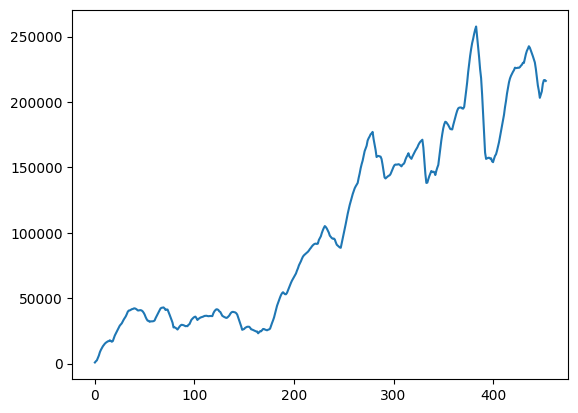

In [513]:
import seaborn as sns
sns.lineplot(combined_df.loc[300, 'cumsum'])

Как говорится, в следующей серии:
- Везде пишем информацию про функции, чтобы было удобно потом работать
- Надо собрать воедино всё, что мы сегодня сделали:
  * Дописать все функции детекции паттернов, сначала для паттернов из 2 свеч, потом для 3 свеч.
  * Написать функцию, которая удобно будет выводит статистические результаты нашиз стратегий после удержания позиции N дней. Надо обязательно разделить на бычьи формации и медвежьи и плясать уже от этого. Может быть стоит убрать такое количество параметров в табличке, так как половина из них неэффективна, оставить основные 5 и всё.
  * Дописать функцию, которая разворачивает датафрейм, написано для 2 свечей, надо до 3 свечей.
  * Дописать функции, создающие новые признаки (поработать со свечками, даты, волатильность и прочее)

- Попробывать придумать механизм для уже обычной торговой системы на основе паттернов, (стоп, тейк) + оптимизация параметров
- Написать итерактивный дашборд, где я смогу визуализировать результаты стратегии
- После изучения машинного обучения, пробуем сделать классификацию или кластеризацию наших паттернов
- Надо объединить процесс создания статистики по какой-либо стратегии, то есть сделать 1 функцию, которая будет получать сырой датафрейм, таймфрейм и формацию, результаты которой мы хотим постмотреть. Так будет хорошо.


Сегодня я вообщем наконец-то нашел подход к написанию паттернов, поэтому следующие напишем достаточно быстро, думаю, что за 1 подход.

Далее надо бы проверить функцию, которая считает результаты наших стратегий.

Когда будут написаны все 7 паттернов и они будут проверены, мы пишем что-то, что позволит собрать все результаты в единный датафрейм для анализа. 

Далее попробуем написать что-то типо оптимизационной функции, которая подбирает автоматически наилучший стоп и тейк.

In [520]:
sber_1h_bull = detection_bullish_engulfing_pattern(sber_1h)

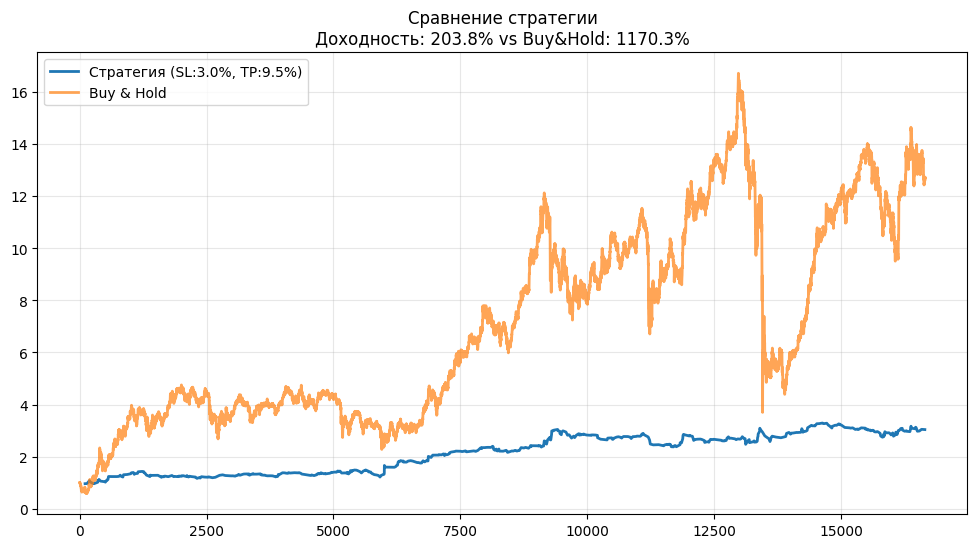

Лучшие параметры: Стоп-лосс 3.0%, Тейк-профит 9.5%
Доходность стратегии: 203.8%
Доходность Buy & Hold: 1170.3%


In [523]:
import pandas as pd
import matplotlib.pyplot as plt

def simple_stop_take_optimize(data, signal_col='signal', price_col='close'):
    """
    Простой подбор стоп-лосса и тейк-профита с сравнением с Buy & Hold
    """
    # Параметры для перебора
    stop_levels = np.arange(0.005, 0.1, 0.005)  # 1%, 2%, 3%, 5%
    take_levels = np.arange(0.005, 0.1, 0.005)  # 2%, 3%, 5%, 8%
    
    best_profit = -1000
    best_stop = 0
    best_take = 0
    
    # Перебираем комбинации
    for stop in stop_levels:
        for take in take_levels:
            profit = test_strategy(data, stop, take, signal_col, price_col)
            if profit > best_profit:
                best_profit = profit
                best_stop = stop
                best_take = take
    
    # Тестируем лучшую стратегию
    strategy_returns = backtest_with_stop_take(data, best_stop, best_take, signal_col, price_col)
    buy_hold_returns = data[price_col].pct_change().fillna(0)
    
    # Строим график
    plt.figure(figsize=(12, 6))
    
    # Доходность стратегии
    strategy_cumulative = (1 + strategy_returns).cumprod()
    plt.plot(strategy_cumulative.index, strategy_cumulative.values, 
             label=f'Стратегия (SL:{best_stop:.1%}, TP:{best_take:.1%})', linewidth=2)
    
    # Buy & Hold
    bh_cumulative = (1 + buy_hold_returns).cumprod()
    plt.plot(bh_cumulative.index, bh_cumulative.values, 
             label='Buy & Hold', linewidth=2, alpha=0.7)
    
    plt.title(f'Сравнение стратегии\nДоходность: {best_profit:.1%} vs Buy&Hold: {bh_cumulative.iloc[-1]-1:.1%}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Лучшие параметры: Стоп-лосс {best_stop:.1%}, Тейк-профит {best_take:.1%}")
    print(f"Доходность стратегии: {best_profit:.1%}")
    print(f"Доходность Buy & Hold: {bh_cumulative.iloc[-1]-1:.1%}")
    
    return best_stop, best_take, best_profit

def test_strategy(data, stop_loss, take_profit, signal_col, price_col):
    """Тестирует одну комбинацию параметров"""
    signals = data[data[signal_col] == 1].index
    total_return = 1.0
    
    for signal_idx in signals:
        entry_idx = data.index.get_loc(signal_idx)
        entry_price = data.iloc[entry_idx][price_col]
        
        # Ищем выход в следующие 5 дней
        for i in range(1, min(6, len(data) - entry_idx)):
            current_price = data.iloc[entry_idx + i][price_col]
            ret = (current_price - entry_price) / entry_price
            
            # Выход по стопу или тейку
            if ret <= -stop_loss or ret >= take_profit or i == 5:
                total_return *= (1 + ret)
                break
    
    return total_return - 1

def backtest_with_stop_take(data, stop_loss, take_profit, signal_col, price_col):
    """Бэктест с фиксированными параметрами"""
    returns = []
    dates = []
    
    signals = data[data[signal_col] == 1].index
    
    for signal_idx in signals:
        entry_idx = data.index.get_loc(signal_idx)
        entry_price = data.iloc[entry_idx][price_col]
        
        for i in range(1, min(6, len(data) - entry_idx)):
            current_idx = entry_idx + i
            current_price = data.iloc[current_idx][price_col]
            ret = (current_price - entry_price) / entry_price
            
            if ret <= -stop_loss or ret >= take_profit or i == 5:
                returns.append(ret)
                dates.append(data.index[current_idx])
                break
    
    return pd.Series(returns, index=dates)

# Использование
best_stop, best_take, profit = simple_stop_take_optimize(sber_1h_bull)